# Dimensionless_Kalshi_ReviewBot_v1

# Kalshi API Explorer and Market Analytics

Corrected, single-file research tool for the Kalshi Trade API v2. Organised into cells for section-by-section use in VS Code/Jupyter, and with a normal-script display fallback.

## Install dependencies
```bash
python -m pip install "requests>=2.32,<3" "cryptography>=44,<47" "python-dotenv>=1,<2" "pandas>=2.2,<4" "numpy>=2,<3" "matplotlib>=3.9,<4" "seaborn>=0.13,<1"
```

Public market-data exploration requires no credentials. To use account endpoints, set `KALSHI_API_KEY_ID` and `KALSHI_PRIVATE_KEY_PATH` in your environment or a local `.env` file. Use `KALSHI_BASE_URL=https://external-api.demo.kalshi.co` for the demo API. Production is the default.

Live order submission is disabled by default (`LIVE_TRADING_ENABLED = False`). This is research code, not financial advice; inspect market rules and test against demo first.


## 1. Imports and configuration


In [1]:
from __future__ import annotations

import base64
import os
import time
import uuid
from decimal import Decimal, InvalidOperation
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from cryptography.hazmat.primitives import hashes, serialization
from cryptography.hazmat.primitives.asymmetric import padding, rsa
from dotenv import load_dotenv

try:
    from IPython.display import display
except ImportError:  # Allows the same file to run as a normal Python script.
    def display(value: Any) -> None:
        print(value)

load_dotenv()

BASE_URL = os.getenv("KALSHI_BASE_URL", "https://external-api.kalshi.com").rstrip("/")
API_PREFIX = "/trade-api/v2"
API_KEY_ID = os.getenv("KALSHI_API_KEY_ID", "").strip()
PRIVATE_KEY_PATH = os.getenv("KALSHI_PRIVATE_KEY_PATH", "").strip()
REQUEST_TIMEOUT_SECONDS = 30
DEFAULT_PAGE_LIMIT = 1000
MAX_GET_RETRIES = 3

# Keep False unless you deliberately want to place real orders.
LIVE_TRADING_ENABLED = False

private_key = None
if API_KEY_ID and PRIVATE_KEY_PATH:
    key_path = Path(PRIVATE_KEY_PATH).expanduser()
    if not key_path.is_file():
        raise FileNotFoundError(
            f"Private key file not found: {key_path}. Check KALSHI_PRIVATE_KEY_PATH."
        )
    with key_path.open("rb") as key_file:
        private_key = serialization.load_pem_private_key(key_file.read(), password=None)

HAS_AUTH_CREDENTIALS = bool(API_KEY_ID and private_key is not None)
session = requests.Session()

print(f"Kalshi base URL: {BASE_URL}")
print(f"Authenticated endpoints configured: {HAS_AUTH_CREDENTIALS}")
print(f"Live order submission enabled: {LIVE_TRADING_ENABLED}")


Kalshi base URL: https://external-api.kalshi.com
Authenticated endpoints configured: False
Live order submission enabled: False


## 2. Authentication, REST requests and pagination

The request signature uses the timestamp + HTTP method + API path (without query parameters). Read-only GET requests may be retried after transient errors. Mutating requests are never retried automatically to avoid accidental duplicate orders.


In [2]:
def _sign_request(method: str, path: str, timestamp_ms: str) -> str:
    if private_key is None:
        raise RuntimeError(
            "No private key loaded. Configure KALSHI_API_KEY_ID and KALSHI_PRIVATE_KEY_PATH."
        )
    canonical_path = path.split("?", 1)[0]
    message = f"{timestamp_ms}{method.upper()}{canonical_path}".encode("utf-8")

    if not isinstance(private_key, rsa.RSAPrivateKey):
        raise TypeError("Kalshi REST authentication requires an RSA private key in PEM format.")
    signature = private_key.sign(
        message,
        padding.PSS(
            mgf=padding.MGF1(hashes.SHA256()),
            salt_length=hashes.SHA256().digest_size,
        ),
        hashes.SHA256(),
    )

    return base64.b64encode(signature).decode("ascii")


def _auth_headers(method: str, path: str) -> dict[str, str]:
    if not API_KEY_ID:
        raise RuntimeError("KALSHI_API_KEY_ID is not configured.")
    timestamp_ms = str(int(time.time() * 1000))
    return {
        "KALSHI-ACCESS-KEY": API_KEY_ID,
        "KALSHI-ACCESS-TIMESTAMP": timestamp_ms,
        "KALSHI-ACCESS-SIGNATURE": _sign_request(method, path, timestamp_ms),
        "Content-Type": "application/json",
        "Accept": "application/json",
    }


def api_request(
    endpoint: str,
    *,
    method: str = "GET",
    params: dict[str, Any] | None = None,
    json_body: dict[str, Any] | None = None,
    authenticated: bool = False,
    timeout: int = REQUEST_TIMEOUT_SECONDS,
) -> dict[str, Any]:
    """Call one Trade API v2 endpoint and return its JSON body."""
    method = method.upper()
    endpoint = "/" + endpoint.lstrip("/")
    path = f"{API_PREFIX}{endpoint}"
    url = f"{BASE_URL}{path}"

    headers: dict[str, str] = {"Accept": "application/json"}
    if authenticated:
        if not HAS_AUTH_CREDENTIALS:
            raise RuntimeError(
                "This endpoint needs API credentials. Set KALSHI_API_KEY_ID and "
                "KALSHI_PRIVATE_KEY_PATH, then restart/re-run the configuration section."
            )
        headers.update(_auth_headers(method, path))

    attempts = MAX_GET_RETRIES if method == "GET" else 1
    response = None
    for attempt in range(attempts):
        try:
            response = session.request(
                method,
                url,
                params=params,
                json=json_body,
                headers=headers,
                timeout=timeout,
            )
        except requests.RequestException:
            if attempt + 1 >= attempts:
                raise
            time.sleep(min(2 ** attempt, 4))
            continue

        if response.status_code in {429, 500, 502, 503, 504} and attempt + 1 < attempts:
            retry_after = response.headers.get("Retry-After", "")
            try:
                delay = min(max(float(retry_after), 0), 10) if retry_after else min(2 ** attempt, 4)
            except ValueError:
                delay = min(2 ** attempt, 4)
            time.sleep(delay)
            continue
        break

    if response is None:
        raise RuntimeError(f"No HTTP response received for {method} {endpoint}.")
    if not response.ok:
        try:
            details = response.json()
        except ValueError:
            details = response.text[:1200]
        raise RuntimeError(f"Kalshi API error {response.status_code} for {method} {endpoint}: {details}")

    try:
        payload = response.json()
    except ValueError as exc:
        raise RuntimeError(f"Kalshi returned non-JSON content for {endpoint}.") from exc
    if not isinstance(payload, dict):
        raise RuntimeError(f"Unexpected response type for {endpoint}: {type(payload).__name__}")
    return payload


def get_all_pages(
    endpoint: str,
    result_key: str,
    *,
    params: dict[str, Any] | None = None,
    limit: int = DEFAULT_PAGE_LIMIT,
    max_pages: int = 5,
    authenticated: bool = False,
) -> list[dict[str, Any]]:
    """Fetch records from cursor-paginated endpoints; max_pages limits API usage."""
    base_params = dict(params or {})
    records: list[dict[str, Any]] = []
    cursor: str | None = None

    for _ in range(max(1, int(max_pages))):
        page_params = dict(base_params)
        page_params["limit"] = min(max(1, int(limit)), 1000)
        if cursor:
            page_params["cursor"] = cursor

        payload = api_request(endpoint, params=page_params, authenticated=authenticated)
        items = payload.get(result_key, []) or []
        if not isinstance(items, list):
            raise RuntimeError(f"Unexpected '{result_key}' format from {endpoint}.")
        records.extend(item for item in items if isinstance(item, dict))

        next_cursor = payload.get("cursor")
        if not next_cursor or next_cursor == cursor:
            break
        cursor = str(next_cursor)

    return records


## 3. Public market-data endpoints


In [9]:
def get_markets(
    *,
    status: str | None = "open",
    series_ticker: str | None = None,
    event_ticker: str | None = None,
    limit: int = DEFAULT_PAGE_LIMIT,
    max_pages: int = 3,
) -> list[dict[str, Any]]:
    params: dict[str, Any] = {}
    if status:
        params["status"] = status
    if series_ticker:
        params["series_ticker"] = series_ticker
    if event_ticker:
        params["event_ticker"] = event_ticker
    return get_all_pages("/markets", "markets", params=params, limit=limit, max_pages=max_pages)


def get_market(ticker: str) -> dict[str, Any]:
    payload = api_request(f"/markets/{ticker}")
    market = payload.get("market", payload)
    if not isinstance(market, dict):
        raise RuntimeError("Unexpected market detail response format.")
    return market


def get_orderbook(ticker: str, *, depth: int = 0) -> dict[str, Any]:
    payload = api_request(f"/markets/{ticker}/orderbook", params={"depth": depth})
    book = payload.get("orderbook_fp", payload.get("orderbook", payload))
    if not isinstance(book, dict):
        raise RuntimeError("Unexpected orderbook response format.")
    return book


def get_events(
    *, status: str | None = "open", limit: int = 500, max_pages: int = 2
) -> list[dict[str, Any]]:
    params: dict[str, Any] = {}
    if status:
        params["status"] = status
    return get_all_pages(
        "/events", "events", params=params,
        limit=min(limit, 200), max_pages=max_pages,
    )


def get_series_list() -> list[dict[str, Any]]:
    payload = api_request("/series")
    result = payload.get("series", []) or []
    return result if isinstance(result, list) else []


def get_trades(
    *, ticker: str | None = None, limit: int = 1000, max_pages: int = 2
) -> list[dict[str, Any]]:
    params: dict[str, Any] = {}
    if ticker:
        params["ticker"] = ticker
    return get_all_pages(
        "/markets/trades", "trades", params=params,
        limit=min(limit, 1000), max_pages=max_pages,
    )

## 4. Fetch and inspect open markets

This cell makes a public, read-only request. The page cap controls request size. Set `status=None` to omit the market status filter.


In [4]:
market_rows = get_markets(status="open", limit=1000, max_pages=3)
market_df_raw = pd.DataFrame(market_rows)
print(f"Open markets retrieved: {len(market_df_raw):,}")

if not market_df_raw.empty:
    liquidity_columns = ("liquidity_dollars", "volume_24h_fp", "volume_fp", "open_interest_fp")
    available_columns = [column for column in liquidity_columns if column in market_df_raw.columns]
    sort_column = next(
        (
            column for column in available_columns
            if pd.to_numeric(market_df_raw[column], errors="coerce").gt(0).any()
        ),
        available_columns[0] if available_columns else None,
    )
    if sort_column:
        market_df_raw = market_df_raw.sort_values(
            sort_column,
            ascending=False,
            na_position="last",
            key=lambda values: pd.to_numeric(values, errors="coerce"),
        )
        print(f"Markets sorted by {sort_column} (highest first).")

    preview_columns = [
        c for c in [
            "ticker", "title", "event_ticker", "series_ticker", "yes_bid_dollars",
            "yes_ask_dollars", "last_price_dollars", "volume_24h_fp", "volume_fp",
            "open_interest_fp", "liquidity_dollars", "close_time",
        ] if c in market_df_raw.columns
    ]
    display(market_df_raw[preview_columns].head(25))
else:
    print("No open markets returned. Try get_markets(status=None) or inspect API access.")

Open markets retrieved: 3,000
Markets sorted by volume_fp (highest first).


,ticker,title,event_ticker,yes_bid_dollars,yes_ask_dollars,last_price_dollars,volume_24h_fp,volume_fp,open_interest_fp,close_time
2699,KXMVECROSSCATEGORY-S20268DCDE955AE5-B2CBF03C29D,"yes Dortmund,yes Tie,yes Shanghai Port,yes Wes...",KXMVECROSSCATEGORY-S20268DCDE955AE5,0.0000,1.0000,0.0006,0.00,71442.85,71442.85,2026-10-12T14:00:00Z
1742,KXMVECROSSCATEGORY-S20263367BA1441F-3A12F12E31A,"yes Aldosivi,yes Gimnasia La Plata,yes Boca Ju...",KXMVECROSSCATEGORY-S20263367BA1441F,0.0001,1.0000,0.0007,0.00,12500.00,12500.00,2026-10-12T18:45:00Z
1985,KXMVECROSSCATEGORY-S2026900BBE06A3C-F9FD37E7861,"yes Matej Dodig,yes Max Alcala Gurri,yes Jonas...",KXMVECROSSCATEGORY-S2026900BBE06A3C,0.0001,1.0000,0.0009,0.00,10000.00,10000.00,2026-10-23T13:00:00Z
1951,KXMVECROSSCATEGORY-S2026A0488757D5B-5150C0AA1BE,"no Vasteraas,no Tie,no Tucuman,no Tie,no Tie,y...",KXMVECROSSCATEGORY-S2026A0488757D5B,0.0000,1.0000,0.0007,0.00,7050.00,7050.00,2026-10-12T03:00:00Z
1700,KXMVECROSSCATEGORY-S2026DDC3202C96B-AA78BF27E1A,"no Tie,no Tie,no Defensa y Justicia,no Tie,yes...",KXMVECROSSCATEGORY-S2026DDC3202C96B,0.0000,1.0000,0.0014,0.00,6666.66,6666.66,2026-10-12T03:00:00Z
1556,KXMVECROSSCATEGORY-S20262785A5B4FEC-D45FF6ED413,"yes Over 0.5 goals scored,yes Over 0.5 goals s...",KXMVECROSSCATEGORY-S20262785A5B4FEC,0.0000,1.0000,0.0038,0.00,6341.46,6341.46,2026-10-12T00:45:00Z
2525,KXMVECROSSCATEGORY-S20264EC31F48821-22899B57D11,"yes Gimnasia La Plata,yes Over 1.5 goals score...",KXMVECROSSCATEGORY-S20264EC31F48821,0.0000,1.0000,0.0017,0.00,5263.15,5263.15,2026-10-14T00:00:00Z
2318,KXMVECROSSCATEGORY-S2026542D6BC711E-D61174178BD,"yes Dortmund,yes Over 2.5 goals scored,yes Wes...",KXMVECROSSCATEGORY-S2026542D6BC711E,0.0000,1.0000,0.0009,0.00,5000.00,5000.00,2026-10-14T16:30:00Z
2665,KXMVECROSSCATEGORY-S2026638E88EB1ED-B56C270CDFC,"yes Goteborg,yes Beveren,yes Heidenheim,yes He...",KXMVECROSSCATEGORY-S2026638E88EB1ED,0.0000,1.0000,0.0005,0.00,5000.00,5000.00,2026-10-11T19:15:00Z
2276,KXMVECROSSCATEGORY-S2026101914FC127-63DB3193FE7,"yes Laslo Djere,yes Luka Mikrut,yes Carlos San...",KXMVECROSSCATEGORY-S2026101914FC127,0.0000,1.0000,0.0058,0.00,3968.25,3968.25,2026-10-23T14:30:00Z


## 5. Liquidity, spread and volume analytics


In [8]:
market_df = market_df_raw.copy()
numeric_columns = [
    "yes_bid_dollars", "yes_ask_dollars", "no_bid_dollars", "no_ask_dollars",
    "last_price_dollars", "previous_price_dollars", "volume_fp",
    "volume_24h_fp", "open_interest_fp", "liquidity_dollars",
]
for column in numeric_columns:
    if column in market_df.columns:
        market_df[column] = pd.to_numeric(market_df[column], errors="coerce")

if {"yes_bid_dollars", "yes_ask_dollars"}.issubset(market_df.columns):
    market_df["spread_dollars"] = market_df["yes_ask_dollars"] - market_df["yes_bid_dollars"]
    market_df["midpoint_dollars"] = (market_df["yes_ask_dollars"] + market_df["yes_bid_dollars"]) / 2
    market_df["spread_pct_of_mid"] = (
        market_df["spread_dollars"] / market_df["midpoint_dollars"].replace(0, np.nan)
    ) * 100

if {"volume_24h_fp", "open_interest_fp"}.issubset(market_df.columns):
    market_df["volume_oi_ratio"] = (
        market_df["volume_24h_fp"] / market_df["open_interest_fp"].replace(0, np.nan)
    )

if not market_df.empty:
    ranking_columns = [
        c for c in ["ticker", "title", "spread_dollars", "spread_pct_of_mid",
                    "liquidity_dollars", "volume_24h_fp", "volume_fp",
                    "open_interest_fp", "volume_oi_ratio"]
        if c in market_df.columns
    ]
    liquidity_columns = ("liquidity_dollars", "volume_24h_fp", "volume_fp", "open_interest_fp")
    available_columns = [column for column in liquidity_columns if column in market_df.columns]
    sort_by = next(
        (column for column in available_columns if market_df[column].gt(0).any()),
        available_columns[0] if available_columns else ranking_columns[0],
    )
    print(f"Markets ranked by {sort_by} (highest first).")
    display(market_df.sort_values(sort_by, ascending=False, na_position="last")[ranking_columns].head(30))
else:
    print("Market table is empty; run the market fetch cell first.")

Markets ranked by volume_fp (highest first).


,ticker,title,spread_dollars,spread_pct_of_mid,volume_24h_fp,volume_fp,open_interest_fp,volume_oi_ratio
2699,KXMVECROSSCATEGORY-S20268DCDE955AE5-B2CBF03C29D,"yes Dortmund,yes Tie,yes Shanghai Port,yes Wes...",1.0000,200.000000,0.0,71442.85,71442.85,0.0
1742,KXMVECROSSCATEGORY-S20263367BA1441F-3A12F12E31A,"yes Aldosivi,yes Gimnasia La Plata,yes Boca Ju...",0.9999,199.960004,0.0,12500.00,12500.00,0.0
1985,KXMVECROSSCATEGORY-S2026900BBE06A3C-F9FD37E7861,"yes Matej Dodig,yes Max Alcala Gurri,yes Jonas...",0.9999,199.960004,0.0,10000.00,10000.00,0.0
1951,KXMVECROSSCATEGORY-S2026A0488757D5B-5150C0AA1BE,"no Vasteraas,no Tie,no Tucuman,no Tie,no Tie,y...",1.0000,200.000000,0.0,7050.00,7050.00,0.0
1700,KXMVECROSSCATEGORY-S2026DDC3202C96B-AA78BF27E1A,"no Tie,no Tie,no Defensa y Justicia,no Tie,yes...",1.0000,200.000000,0.0,6666.66,6666.66,0.0
1556,KXMVECROSSCATEGORY-S20262785A5B4FEC-D45FF6ED413,"yes Over 0.5 goals scored,yes Over 0.5 goals s...",1.0000,200.000000,0.0,6341.46,6341.46,0.0
2525,KXMVECROSSCATEGORY-S20264EC31F48821-22899B57D11,"yes Gimnasia La Plata,yes Over 1.5 goals score...",1.0000,200.000000,0.0,5263.15,5263.15,0.0
2318,KXMVECROSSCATEGORY-S2026542D6BC711E-D61174178BD,"yes Dortmund,yes Over 2.5 goals scored,yes Wes...",1.0000,200.000000,0.0,5000.00,5000.00,0.0
2665,KXMVECROSSCATEGORY-S2026638E88EB1ED-B56C270CDFC,"yes Goteborg,yes Beveren,yes Heidenheim,yes He...",1.0000,200.000000,0.0,5000.00,5000.00,0.0
2276,KXMVECROSSCATEGORY-S2026101914FC127-63DB3193FE7,"yes Laslo Djere,yes Luka Mikrut,yes Carlos San...",1.0000,200.000000,0.0,3968.25,3968.25,0.0


## 6. Plot spread versus 24-hour volume

A tight quoted spread or high volume is a descriptive signal, not a guarantee of execution quality or profitability.


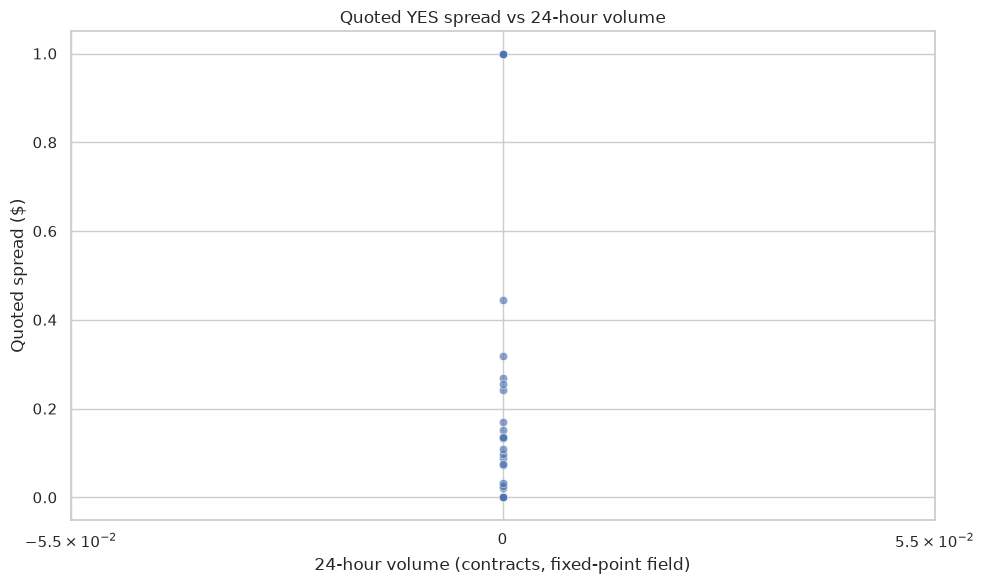

In [6]:
sns.set_theme(context="notebook", style="whitegrid")

plot_df = market_df.copy()
if {"spread_dollars", "volume_24h_fp"}.issubset(plot_df.columns):
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["spread_dollars", "volume_24h_fp"])
    plot_df = plot_df[(plot_df["spread_dollars"] >= 0) & (plot_df["volume_24h_fp"] >= 0)]
    if not plot_df.empty:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=plot_df, x="volume_24h_fp", y="spread_dollars", alpha=0.65)
        plt.xscale("symlog", linthresh=1)
        plt.title("Quoted YES spread vs 24-hour volume")
        plt.xlabel("24-hour volume (contracts, fixed-point field)")
        plt.ylabel("Quoted spread ($)")
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough non-missing spread/volume rows to plot.")
else:
    print("Spread/volume fields are not present in the market response.")


## 7. Explore events and series


In [10]:
event_rows = get_events(status="open", limit=500, max_pages=2)
events_df = pd.DataFrame(event_rows)
print(f"Open events retrieved: {len(events_df):,}")
if not events_df.empty:
    columns = [c for c in ["event_ticker", "title", "category", "series_ticker", "sub_title"] if c in events_df]
    display(events_df[columns].head(20) if columns else events_df.head(20))
else:
    print("No open events returned.")


Open events retrieved: 400


,event_ticker,title,category,series_ticker,sub_title
0,KXELONMARS-99,Will Elon Musk visit Mars in his lifetime?,World,KXELONMARS,Before 2099
1,KXNEXTNATOSECGEN-99,Who will be the next Secretary General of NATO?,Elections,KXNEXTNATOSECGEN,"Before Jan 1, 2099"
2,KXNEWPOPE-70,Who will the next Pope be?,Elections,KXNEWPOPE,Before 2070
3,KXWARMING-50,Will the world pass 2 degrees Celsius over pre...,Climate and Weather,KXWARMING,Before 2050
4,KXMARSVRAIL-50,Will a human land on Mars before California st...,Science and Technology,KXMARSVRAIL,Before 2050
5,KXERUPTSUPER-0,Will a supervolcano erupt before 2050?,Climate and Weather,KXERUPTSUPER,a supervolcano
6,KXCOLONIZEMARS-50,Will humans colonize Mars before 2050?,Science and Technology,KXCOLONIZEMARS,Before 2050
7,KXPERSONPRESMAM-45,Will Zohran Mamdani become President of the Un...,Politics,KXPERSONPRESMAM,"Before Jan 22, 2045"
8,KXNEXTDNCCHAIR-45,Who will be the next DNC Chair?,Politics,KXNEXTDNCCHAIR,"Before Jan 1, 2045"
9,KXMILLENNIUMNEXT-45,Which Millennium Prize Problem will be solved ...,Science and Technology,KXMILLENNIUMNEXT,Before 2045


In [ ]:
series_rows = get_series_list()
series_df = pd.DataFrame(series_rows)
print(f"Series returned: {len(series_df):,}")
if not series_df.empty:
    columns = [c for c in ["ticker", "title", "category", "frequency"] if c in series_df]
    display(series_df[columns].head(30) if columns else series_df.head(30))
else:
    print("No series returned.")


## 8. Choose one market for order-book and trade analysis

The first open market is only a starting point. Review the title and ticker, then manually set `SELECTED_TICKER` if needed.


In [11]:
SELECTED_TICKER = (
    str(market_df_raw.iloc[0]["ticker"])
    if not market_df_raw.empty and "ticker" in market_df_raw.columns
    else ""
)

selected_market: dict[str, Any] = {}
if SELECTED_TICKER:
    print("Selected ticker:", SELECTED_TICKER)
    try:
        selected_market = get_market(SELECTED_TICKER)
        detail_keys = [
            "ticker", "title", "subtitle", "event_ticker", "series_ticker", "status",
            "yes_bid_dollars", "yes_ask_dollars", "last_price_dollars", "volume_24h_fp",
            "open_interest_fp", "close_time", "rules_primary", "rules_secondary",
        ]
        display(pd.Series({key: selected_market.get(key) for key in detail_keys}, name="Market details"))
    except Exception as exc:
        print("Market detail request failed:", exc)
else:
    print("No open market was returned. Set SELECTED_TICKER manually to a current market ticker.")


Selected ticker: KXMVECROSSCATEGORY-S20268DCDE955AE5-B2CBF03C29D


ticker                  KXMVECROSSCATEGORY-S20268DCDE955AE5-B2CBF03C29D
title                 yes Dortmund,yes Tie,yes Shanghai Port,yes Wes...
subtitle                                                            NaN
event_ticker                        KXMVECROSSCATEGORY-S20268DCDE955AE5
series_ticker                                                       NaN
status                                                           active
yes_bid_dollars                                                  0.0001
yes_ask_dollars                                                  1.0000
last_price_dollars                                               0.0006
volume_24h_fp                                                      0.00
open_interest_fp                                               71442.85
close_time                                         2026-10-12T14:00:00Z
rules_primary                                                          
rules_secondary       Kalshi is not affiliated, associated, auth

## 9. Order-book depth and implied prices

The current response includes YES bids and NO bids. Since array ordering can be easy to misread, this code finds each best bid with `max(price)` rather than relying on the first or last row. The implied YES ask is `1 - best NO bid`.


In [13]:
orderbook_levels = pd.DataFrame(columns=["side", "price_dollars", "contracts"])
best_yes_bid = np.nan
best_no_bid = np.nan
best_yes_ask = np.nan
best_no_ask = np.nan

if SELECTED_TICKER:
    try:
        orderbook = get_orderbook(SELECTED_TICKER, depth=0)
        book_rows: list[dict[str, Any]] = []
        for label, levels in [("YES bid", orderbook.get("yes_dollars", [])),
                              ("NO bid", orderbook.get("no_dollars", []))]:
            for level in levels or []:
                if isinstance(level, (list, tuple)) and len(level) >= 2:
                    price = pd.to_numeric(level[0], errors="coerce")
                    quantity = pd.to_numeric(level[1], errors="coerce")
                    if pd.notna(price) and pd.notna(quantity):
                        book_rows.append({"side": label, "price_dollars": float(price), "contracts": float(quantity)})
        orderbook_levels = pd.DataFrame(book_rows, columns=["side", "price_dollars", "contracts"])

        yes_prices = orderbook_levels.loc[orderbook_levels["side"] == "YES bid", "price_dollars"]
        no_prices = orderbook_levels.loc[orderbook_levels["side"] == "NO bid", "price_dollars"]
        if not yes_prices.empty:
            best_yes_bid = float(yes_prices.max())
            best_no_ask = 1.0 - best_yes_bid
        if not no_prices.empty:
            best_no_bid = float(no_prices.max())
            best_yes_ask = 1.0 - best_no_bid

        print("Best YES bid:", f"${best_yes_bid:.4f}" if pd.notna(best_yes_bid) else "unavailable")
        print("Implied YES ask:", f"${best_yes_ask:.4f}" if pd.notna(best_yes_ask) else "unavailable")
        print("Best NO bid:", f"${best_no_bid:.4f}" if pd.notna(best_no_bid) else "unavailable")
        display(orderbook_levels.head(30))
    except Exception as exc:
        print("Orderbook request failed:", exc)
else:
    print("Set SELECTED_TICKER first.")


Best YES bid: $0.0001
Implied YES ask: unavailable
Best NO bid: unavailable


,side,price_dollars,contracts
0,YES bid,0.0001,71442.0


In [ ]:
if not orderbook_levels.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=orderbook_levels, x="price_dollars", y="contracts", hue="side", errorbar=None)
    plt.title(f"Order-book levels — {SELECTED_TICKER}")
    plt.xlabel("Bid price ($)")
    plt.ylabel("Contracts at level")
    plt.tight_layout()
    plt.show()
    display(orderbook_levels.groupby("side", as_index=False)["contracts"].sum().rename(columns={"contracts": "visible_contracts"}))


## 10. Recent trades and sample VWAP


In [14]:
trades_df = pd.DataFrame()
if SELECTED_TICKER:
    try:
        trades_df = pd.DataFrame(get_trades(ticker=SELECTED_TICKER, limit=1000, max_pages=2))
        if not trades_df.empty:
            for column in ["yes_price_dollars", "no_price_dollars", "count_fp"]:
                if column in trades_df.columns:
                    trades_df[column] = pd.to_numeric(trades_df[column], errors="coerce")
            if {"yes_price_dollars", "count_fp"}.issubset(trades_df.columns):
                trades_df["yes_notional_dollars"] = trades_df["yes_price_dollars"] * trades_df["count_fp"]
                total_count = trades_df["count_fp"].sum(min_count=1)
                sample_vwap = trades_df["yes_notional_dollars"].sum(min_count=1) / total_count if pd.notna(total_count) and total_count > 0 else np.nan
                print(f"Fetched trade rows: {len(trades_df):,}")
                print(f"Sample trade quantity: {total_count}")
                print("Sample YES-price VWAP:", f"${sample_vwap:.4f}" if pd.notna(sample_vwap) else "unavailable")
            display(trades_df.head(20))
        else:
            print("No recent trades returned for this ticker.")
    except Exception as exc:
        print("Trade request failed:", exc)
else:
    print("Set SELECTED_TICKER first.")


Fetched trade rows: 1
Sample trade quantity: 71442.85
Sample YES-price VWAP: $0.0006


,count_fp,created_time,is_block_trade,no_price_dollars,taker_book_side,taker_outcome_side,taker_side,ticker,trade_id,yes_price_dollars,yes_notional_dollars
0,71442.85,2026-10-09T13:17:43.95469Z,False,0.9994,bid,yes,yes,KXMVECROSSCATEGORY-S20268DCDE955AE5-B2CBF03C29D,0725a3f0-1bb9-8355-47d3-5c252d5f884b,0.0006,42.86571


## 11. Candlesticks and descriptive indicators

Candlesticks require both a real series ticker and market ticker. The series ticker is read from the market when present; otherwise a prefix is suggested as a convenience only. **Check `SERIES_TICKER` before interpreting results.** Supported intervals are 1, 60 and 1440 minutes.


In [15]:
SERIES_TICKER = str(selected_market.get("series_ticker") or (SELECTED_TICKER.split("-")[0] if SELECTED_TICKER else "")).strip()
# If the inferred ticker is not correct, replace it manually, e.g. SERIES_TICKER = "KX..."
PERIOD_INTERVAL_MINUTES = 1
LOOKBACK_HOURS = 24
candles_df = pd.DataFrame()

if SELECTED_TICKER and SERIES_TICKER:
    end_ts = int(time.time())
    start_ts = end_ts - int(LOOKBACK_HOURS * 3600)
    try:
        candles_df = pd.DataFrame(get_candlesticks(
            SERIES_TICKER,
            SELECTED_TICKER,
            start_ts=start_ts,
            end_ts=end_ts,
            period_interval=PERIOD_INTERVAL_MINUTES,
        ))
        print(f"Candlesticks returned: {len(candles_df):,}")
    except Exception as exc:
        print("Candlestick request failed. Verify the exact series and market tickers.")
        print(exc)
else:
    print("Set SELECTED_TICKER and SERIES_TICKER first.")


Candlesticks returned: 1


In [ ]:
if not candles_df.empty:
    if "price" in candles_df.columns:
        price_rows = candles_df["price"].apply(lambda value: value if isinstance(value, dict) else {})
    else:
        price_rows = pd.Series([{} for _ in range(len(candles_df))], index=candles_df.index)

    for field in ["open_dollars", "high_dollars", "low_dollars", "close_dollars", "mean_dollars"]:
        candles_df[field] = pd.to_numeric(price_rows.apply(lambda value: value.get(field, np.nan)), errors="coerce")
    for field in ["volume_fp", "open_interest_fp"]:
        if field in candles_df.columns:
            candles_df[field] = pd.to_numeric(candles_df[field], errors="coerce")

    time_column = "end_period_ts" if "end_period_ts" in candles_df.columns else ("end_ts" if "end_ts" in candles_df.columns else None)
    if time_column:
        candles_df["timestamp"] = pd.to_datetime(candles_df[time_column], unit="s", utc=True, errors="coerce")
        candles_df = candles_df.sort_values("timestamp").set_index("timestamp")

    candles_df["return"] = candles_df["close_dollars"].pct_change()
    positive_close = candles_df["close_dollars"].where(candles_df["close_dollars"] > 0)
    candles_df["log_return"] = np.log(positive_close).diff()
    candles_df["sma_20"] = candles_df["close_dollars"].rolling(20, min_periods=5).mean()
    candles_df["ema_20"] = candles_df["close_dollars"].ewm(span=20, adjust=False).mean()
    candles_df["rolling_volatility_20"] = candles_df["return"].rolling(20, min_periods=5).std()

    price_change = candles_df["close_dollars"].diff()
    gains = price_change.clip(lower=0)
    losses = -price_change.clip(upper=0)
    avg_gain = gains.rolling(14, min_periods=14).mean()
    avg_loss = losses.rolling(14, min_periods=14).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    candles_df["rsi_14"] = 100 - (100 / (1 + rs))
    candles_df.loc[(avg_loss == 0) & (avg_gain > 0), "rsi_14"] = 100

    if "volume_fp" in candles_df.columns:
        volume_mean = candles_df["volume_fp"].rolling(20, min_periods=5).mean()
        volume_std = candles_df["volume_fp"].rolling(20, min_periods=5).std().replace(0, np.nan)
        candles_df["volume_zscore_20"] = (candles_df["volume_fp"] - volume_mean) / volume_std

    display(candles_df.tail(20))
else:
    print("No candlesticks available; indicator calculations skipped.")


In [ ]:
if not candles_df.empty and "close_dollars" in candles_df.columns:
    plt.figure(figsize=(12, 5))
    plt.plot(candles_df.index, candles_df["close_dollars"], label="Close")
    plt.plot(candles_df.index, candles_df["sma_20"], label="SMA 20")
    plt.plot(candles_df.index, candles_df["ema_20"], label="EMA 20")
    plt.title(f"Price and moving averages — {SELECTED_TICKER}")
    plt.xlabel("Time (UTC)")
    plt.ylabel("Price ($)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(candles_df.index, candles_df["rolling_volatility_20"], label="Rolling volatility (20)")
    ax1.set_xlabel("Time (UTC)")
    ax1.set_ylabel("Rolling return volatility")
    if "volume_fp" in candles_df.columns:
        ax2 = ax1.twinx()
        ax2.bar(candles_df.index, candles_df["volume_fp"], alpha=0.25, label="Volume")
        ax2.set_ylabel("Volume (contracts)")
    plt.title("Rolling volatility and volume")
    fig.tight_layout()
    plt.show()


## 12. Market metric correlation heatmap

Correlation is descriptive and does not establish cause or predict future prices.


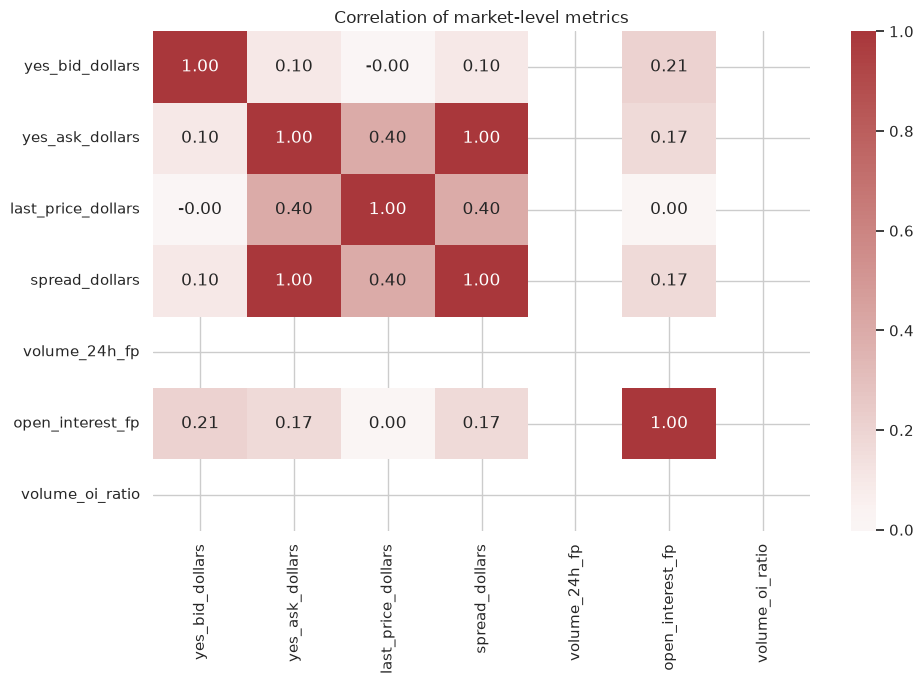

In [16]:
candidate_features = [
    "yes_bid_dollars", "yes_ask_dollars", "last_price_dollars",
    "spread_dollars", "volume_24h_fp", "open_interest_fp",
    "liquidity_dollars", "volume_oi_ratio",
]
available_features = [column for column in candidate_features if column in market_df.columns]
if len(available_features) >= 2:
    correlation = market_df[available_features].corr(numeric_only=True)
    plt.figure(figsize=(10, 7))
    sns.heatmap(correlation, annot=True, fmt=".2f", center=0, cmap="vlag")
    plt.title("Correlation of market-level metrics")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric fields for a correlation heatmap.")


## 13. Optional authenticated account reads

These functions do not run automatically. Start by reading balance/positions in the demo environment.


In [ ]:
def get_balance() -> dict[str, Any]:
    return api_request("/portfolio/balance", authenticated=True)


def get_positions(*, limit: int = 1000, max_pages: int = 3) -> list[dict[str, Any]]:
    return get_all_pages(
        "/portfolio/positions", "market_positions", limit=limit,
        max_pages=max_pages, authenticated=True,
    )


def get_resting_orders(*, limit: int = 1000, max_pages: int = 3) -> list[dict[str, Any]]:
    return get_all_pages(
        "/portfolio/events/orders", "orders", params={"status": "resting"},
        limit=limit, max_pages=max_pages, authenticated=True,
    )

# Uncomment individually after configuring credentials:
# display(get_balance())
# display(pd.DataFrame(get_positions()))
# display(pd.DataFrame(get_resting_orders()))


## 14. Guarded order submission example

This creates a YES bid using the V2 endpoint shape. The helper refuses to submit until you manually set `LIVE_TRADING_ENABLED = True`. It does not automatically retry a write request. Confirm the environment, market, price, count, permissions and market rules before enabling.


In [ ]:
def _fixed_point(value: str | int | float | Decimal, places: int = 2) -> str:
    try:
        number = Decimal(str(value))
    except InvalidOperation as exc:
        raise ValueError(f"Invalid numeric value: {value!r}") from exc
    if not number.is_finite():
        raise ValueError("Value must be finite.")
    quantum = Decimal("1").scaleb(-places)
    return format(number.quantize(quantum), f".{places}f")


def submit_yes_bid(
    ticker: str,
    *,
    count: str | int | float | Decimal,
    price_dollars: str | int | float | Decimal,
    time_in_force: str = "fill_or_kill",
) -> dict[str, Any]:
    """Create one V2 YES bid. Real submission requires explicit opt-in."""
    if not LIVE_TRADING_ENABLED:
        raise RuntimeError(
            "Live orders are disabled. Review the code and test with the demo API first; "
            "then explicitly set LIVE_TRADING_ENABLED = True if appropriate."
        )
    if not HAS_AUTH_CREDENTIALS:
        raise RuntimeError("API key and private key are required to place orders.")
    if not ticker or not isinstance(ticker, str):
        raise ValueError("ticker must be a non-empty market ticker.")

    count_text = _fixed_point(count, places=2)
    price_text = _fixed_point(price_dollars, places=4)
    if Decimal(count_text) <= 0:
        raise ValueError("count must be greater than zero.")
    if not Decimal("0") < Decimal(price_text) < Decimal("1"):
        raise ValueError("price_dollars must be greater than $0 and less than $1.")
    if time_in_force not in {"fill_or_kill", "good_till_canceled", "immediate_or_cancel"}:
        raise ValueError("Unsupported time_in_force value.")

    order_body = {
        "ticker": ticker,
        "client_order_id": str(uuid.uuid4()),
        "side": "bid",
        "count": count_text,
        "price": price_text,
        "time_in_force": time_in_force,
        "self_trade_prevention_type": "taker_at_cross",
    }
    # Do not automatically retry POST /orders: a timeout can occur after the exchange accepted it.
    return api_request(
        "/portfolio/events/orders",
        method="POST",
        json_body=order_body,
        authenticated=True,
    )

# Intentionally not executed:
# order_result = submit_yes_bid(SELECTED_TICKER, count="1.00", price_dollars="0.0100")
# display(order_result)


## 15. Export analysis tables to CSV

Files are saved locally in `kalshi_analytics/`.


In [ ]:
export_dir = Path("kalshi_analytics")
export_dir.mkdir(parents=True, exist_ok=True)

export_tables = {
    "markets.csv": market_df,
    "events.csv": events_df,
    "series.csv": series_df,
    "orderbook_levels.csv": orderbook_levels,
    "trades.csv": trades_df,
    "candlesticks_features.csv": candles_df.reset_index() if not candles_df.empty else candles_df,
}
for filename, dataframe in export_tables.items():
    if isinstance(dataframe, pd.DataFrame) and not dataframe.empty:
        dataframe.to_csv(export_dir / filename, index=False)
        print(f"Saved {export_dir / filename} ({len(dataframe):,} rows)")
print("Export step complete.")


## 16. Local self-checks

These checks validate local structures and basic numeric bounds, not network credentials or order acceptance.


In [ ]:
assert isinstance(market_rows, list), "Market response should be a list."
assert isinstance(market_df, pd.DataFrame), "Market analytics should be a DataFrame."
assert not LIVE_TRADING_ENABLED or HAS_AUTH_CREDENTIALS, (
    "Live trading is enabled but API credentials are not configured."
)
if not orderbook_levels.empty:
    prices = orderbook_levels["price_dollars"].dropna()
    quantities = orderbook_levels["contracts"].dropna()
    assert prices.between(0, 1).all(), "Order-book prices should be between $0 and $1."
    assert (quantities >= 0).all(), "Order-book quantities must be non-negative."
print("Local self-checks passed.")
print("Before interpreting results, verify the selected market and series tickers.")
